In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=np.VisibleDeprecationWarning) # Polyfit uyarısı
import gc

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [2]:
pd.set_option("display.max_columns",None)
pd.set_option("display.width",500)

In [3]:
df_customer_history = pd.read_csv("customer_history.csv")
df_customer = pd.read_csv("customers.csv")
df_referance = pd.read_csv("referance_data.csv")
df_referance_test = pd.read_csv("referance_data_test.csv")

In [4]:
#FONKSİYONLAR

def df_onizleme(df):
    print(f"describe :  \n {df.describe()}")
    print("########################################################")
    print(f"nunique :  \n {df.nunique()}")
    print("########################################################")
    print(f"null counts : \n {df.isnull().sum()}")
    print("########################################################")
    print(f"info : \n {df.info()}")

def max_date_is_eq_ref_date(df):
    df_copy = df.copy()
    a = df_copy.groupby(["cust_id","ref_date"])["date"].max().reset_index()
    print(a[a["date"] != a["ref_date"]].count())


def ikili_karsilastirma(df,col1,col2,tru=0):

    d=df.groupby([col1,col2]).size().reset_index()
    print(d)
    if(tru == 1):
        plt.title(col1 + " -- "+ col2)
        plt.xlabel(col1+"-"+col2)
        d.plot(kind='bar',figsize=(20,10))
        plt.show()

def plot_category_count(df):
    cols = [col for col in df.columns if df[col].dtype == "object"]
    for col in cols:
        col_plot = df[col].value_counts()
        col_plot.plot(kind='bar',figsize=(12,8))
        plt.title(col)
        plt.xlabel(col)
        plt.ylabel("count")
        plt.show()

def categorical_col_churn_analysis(df):
    cat_cols = [col for col in df.columns if df[col].dtype == "object"]
    for col in cat_cols:
        plt_cols = df.groupby(col)["churn"].mean()
        plt_cols.plot(kind='bar')
        plt.title(f"churn - {col}")
        plt.show()

def numerical_col_churn_analysis(df , max_unique = 20):
    not_in = ["mobile_eft_all_amt","cc_transaction_all_amt","cust_id","churn"]
    num_cols = [col for col in df.columns if df[col].dtype != "object" and col not in not_in]
    for col in num_cols:
        num_unique = df[col].nunique()
        if num_unique > max_unique:
            new_col = df.groupby(pd.cut(df[col],bins=60))["churn"].mean()
            new_col.plot(kind='bar')
            plt.title(f"churn - {col}")
        else:
            plt_cols = df.groupby(col)["churn"].mean()
            plt_cols.plot(kind='bar')
            plt.title(f"churn - {col}")
        plt.show()

def transaction_aim_for_churn_0(df,churn_value = 0):
    df_copy = df.copy()
    #churn değeri 0 olanlar için yıl bazlı harcama tablosu
    df_copy = df_copy[df_copy["churn"] == churn_value]

    plt.figure(figsize=(20, 15))
    # ay bazlı işlem ortalamaları
    monthly_agg = df_copy.groupby(pd.Grouper(key='date', freq='ME')).agg({
        'mobile_eft_all_cnt': 'mean',
        'mobile_eft_all_amt': 'mean',
        'cc_transaction_all_amt': 'mean',
        'cc_transaction_all_cnt': 'mean',
        'active_product_category_nbr': 'mean'
    }).reset_index()

    plt.title(f"Transaction Aim for Churn {churn_value}")

    plt.subplot(3, 2, 1)
    plt.plot(monthly_agg['date'], monthly_agg['mobile_eft_all_cnt'], marker='o')
    plt.title('Average Mobile EFT Count Over Time')
    plt.xticks(rotation=45)

    plt.subplot(3, 2, 2)
    plt.plot(monthly_agg['date'], monthly_agg['mobile_eft_all_amt'], marker='o', color='orange')
    plt.title('Average Mobile EFT Amount Over Time')
    plt.xticks(rotation=45)

    plt.subplot(3, 2, 3)
    plt.plot(monthly_agg['date'], monthly_agg['cc_transaction_all_amt'], marker='o', color='green')
    plt.title('Average Credit Card Transaction Amount Over Time')
    plt.xticks(rotation=45)

    plt.subplot(3, 2, 4)
    plt.plot(monthly_agg['date'], monthly_agg['cc_transaction_all_cnt'], marker='o', color='red')
    plt.title('Average Credit Card Transaction Count Over Time')
    plt.xticks(rotation=45)

    plt.subplot(3, 2, 5)
    plt.plot(monthly_agg['date'], monthly_agg['active_product_category_nbr'], marker='o', color='purple')
    plt.title('Average Active Product Categories Over Time')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


def tenure_in_data(df):
    """
    her biir customer için veri setindeki tarih aralığının ay bazında gösterir yani datadaki tenure sayısını
    column name = active_tenure
    """
    df_copy = df.copy()

    diff = df_copy.groupby("cust_id")["date"].agg(["max","min"]) #lambda ile tek saturda yapmak yerine daha hızlı çözüm
    diff["active_tenure"] = ((diff["max"] - diff["min"]).dt.days / 30).round().astype(int)
    diff = diff.reset_index()
    diff = diff.drop(columns=["max","min"])

    return diff


def harcama_tenure_oranı(df):
    """
    customerlerin günlük ortalama değerleri
    """

    df_copy = df.copy()
    active_tenure=tenure_in_data(df_copy)
    df_copy = df_copy.merge(active_tenure, how='left', on='cust_id')

    sum_val = df_copy.groupby("cust_id").agg({
        "mobile_eft_all_amt" : "sum",
        "cc_transaction_all_amt" : "sum",
        "mobile_eft_all_cnt" : "sum",
        "cc_transaction_all_cnt" : "sum",
        "tenure" : "min",
        "active_tenure" : "min"
    })



    cols = ["mobile_eft_all_amt","cc_transaction_all_amt","mobile_eft_all_cnt","cc_transaction_all_cnt"]
    for col in cols:
        sum_val[f"{col}_tenure_ratio"] = sum_val[col]/sum_val["active_tenure"] #aktif olduğu süre bazında

    sum_val = sum_val.drop(columns=["mobile_eft_all_amt","cc_transaction_all_amt","mobile_eft_all_cnt","cc_transaction_all_cnt"])

    #print(sum_val)
    return sum_val



    """
    #rationun churn üzerindeki etkisine bakmak için

    sum_val["eft_ratio_bin"] = pd.qcut(sum_val["mobile_eft_all_amt_tenure_ratio"], 30, duplicates='drop')
    sum_val["cc_ratio_bin"] = pd.qcut(sum_val["cc_transaction_all_amt_tenure_ratio"], 30, duplicates='drop')
    sum_val["mobile_cnt"] = pd.qcut(sum_val["mobile_eft_all_cnt_tenure_ratio"], 30, duplicates='drop')
    sum_val["cc_cnt"] = pd.qcut(sum_val["cc_transaction_all_cnt_tenure_ratio"], 30, duplicates='drop')



    # Her oran aralığına göre ortalama churn oranını hesapla
    eft_churn = sum_val.groupby("eft_ratio_bin")["churn"].mean()
    cc_churn = sum_val.groupby("cc_ratio_bin")["churn"].mean()
    mobile_cnt = sum_val.groupby(["mobile_cnt"])["churn"].mean()
    cc_tr_cnt = sum_val.groupby(["cc_cnt"])["churn"].mean()

    plt.figure(figsize=(12, 5))

    plt.subplot(2, 2, 1)
    eft_churn.plot(kind="bar", rot=45)
    plt.title("Mobile EFT / Tenure Oranı'na Göre Ortalama Churn")
    plt.ylabel("Ortalama Churn Oranı")
    plt.xlabel("Mobile EFT / Tenure Oranı Aralığı")

    plt.subplot(2, 2, 2)
    cc_churn.plot(kind="bar", rot=45)
    plt.title("Kredi Kartı / Tenure Oranı'na Göre Ortalama Churn")
    plt.ylabel("Ortalama Churn Oranı")
    plt.xlabel("CC / Tenure Oranı Aralığı")

    plt.tight_layout()
    plt.show()

    plt.subplot(2, 2, 3)
    mobile_cnt.plot(kind="bar", rot=45)
    plt.title("mobile count / Tenure Oranı'na Göre Ortalama Churn")
    plt.ylabel("Ortalama Churn Oranı")
    plt.xlabel("mobile_count / Tenure Oranı Aralığı")

    plt.subplot(2, 2, 4)
    cc_tr_cnt.plot(kind="bar", rot=45)
    plt.title("cc count / Tenure Oranı'na Göre Ortalama Churn")
    plt.ylabel("Ortalama Churn Oranı")
    plt.xlabel("CC / Tenure Oranı Aralığı")

    plt.tight_layout()
    plt.show()
    """


def calculate_slope(series):
    """
    lineer regrasyon eğimini hesaplama
    harcama tutarlarının zaman aralığında lineer olarak eğilimin hesaplamak için
    """

    if len(series) < 2:  # eğer 2'den az veri varsa hesaplama olamaz
        return 0

    # y=harcama x=zaman
    y = series.values
    x = np.arange(len(series))

    # 1.dereceden polinom
    # sonuç [slope,intercept]
    slope = np.polyfit(x, y, 1)[0]
    return slope


def monthly_numerical_analysis(df, start_month, end_month, suffix):
    """
    Belirtilen ay aralığındaki (start_month < month_diff <= end_month)
    sayısal işlem değerlerinin istatistiklerini hesaplar.
    Sadece son dönemler için (start_month=0) trend hesaplar.
    """
    df_copy = df.copy()  # Orijinal df'i bozmamak için kopyala

    num_col = ["mobile_eft_all_cnt", "active_product_category_nbr", "mobile_eft_all_amt",
               "cc_transaction_all_amt", "cc_transaction_all_cnt"]

    # Month_diff hesaplaması
    # ÖNEMLİ: df_copy üzerinde bu sütunu oluşturuyoruz
    df_copy["month_diff"] = ((df_copy["ref_date"].dt.year - df_copy["date"].dt.year) * 12 +
                             (df_copy["ref_date"].dt.month - df_copy["date"].dt.month)).astype(int)

    # Belirtilen ay aralığındaki veriyi filtrele
    window_data = df_copy[(df_copy["month_diff"] > start_month) & (df_copy["month_diff"] <= end_month)]

    # Pencerede hiç veri yoksa, merge edilebilecek boş bir DF döndür
    if window_data.empty:
        print(f"Uyarı: {suffix} aralığı ({start_month}-{end_month}) için veri bulunamadı. Boş DF döndürülüyor.")
        # Anahtar sütunları içeren boş DF döndür
        # Tüm olası cust_id, ref_date kombinasyonlarını al
        all_keys = df[['cust_id', 'ref_date']].drop_duplicates().reset_index(drop=True)
        return all_keys

    # Temel Aggregations
    agg_funcs_dict = {
        **{f"{col}_{func}": (col, func) for col in num_col for func in ["mean", "std", "max", "min", "last", "sum"]}}
    agg_funcs_dict["date_count"] = ("date", "count")  # Aktif ay sayısı

    agg_features = window_data.groupby(["cust_id", "ref_date"]).agg(**agg_funcs_dict).reset_index()

    # Zeros Count Hesaplamaları (pencere verisi üzerinden)
    mobile_eft_zeros_count = window_data.groupby(["cust_id", "ref_date"])["mobile_eft_all_cnt"].agg(
        lambda x: (x == 0).sum()).reset_index(name='mobile_eft_zeros_count')
    cc_transaction_zeros_count = window_data.groupby(["cust_id", "ref_date"])["cc_transaction_all_cnt"].agg(
        lambda x: (x == 0).sum()).reset_index(name='cc_transaction_zeros_count')

    # Merge Zeros Count
    agg_features = agg_features.merge(mobile_eft_zeros_count, on=["cust_id", "ref_date"], how='left')
    agg_features = agg_features.merge(cc_transaction_zeros_count, on=["cust_id", "ref_date"], how='left')

    # NaN Doldurma (Zeros Count için - merge sonrası oluşabilir) -> 0 doldurmak daha güvenli
    agg_features['mobile_eft_zeros_count'] = agg_features['mobile_eft_zeros_count'].fillna(0)
    agg_features['cc_transaction_zeros_count'] = agg_features['cc_transaction_zeros_count'].fillna(0)

    # Trend Hesaplama (Sadece son dönemler için, start_month=0 ise)
    if start_month == 0:
        # Trend için veriyi sırala
        window_data_sorted = window_data.sort_values(by=['cust_id', 'ref_date', 'date'])

        slope_mobile = window_data_sorted.groupby(["cust_id", "ref_date"])["mobile_eft_all_amt"].apply(
            calculate_slope).reset_index(name='trend_mobile')
        slope_cc_transaction = window_data_sorted.groupby(["cust_id", "ref_date"])["cc_transaction_all_amt"].apply(
            calculate_slope).reset_index(name='trend_cc_transaction')

        # Merge Trend Features
        agg_features = agg_features.merge(slope_mobile, on=["cust_id", "ref_date"], how='left')
        agg_features = agg_features.merge(slope_cc_transaction, on=["cust_id", "ref_date"], how='left')

        # NaN Doldurma (Trend için - merge sonrası veya hesaplanamama durumu)
        agg_features['trend_mobile'] = agg_features['trend_mobile'].fillna(0)
        agg_features['trend_cc_transaction'] = agg_features['trend_cc_transaction'].fillna(0)

    # Std NaN Doldurma (Eğer sadece 1 ay veri varsa std NaN olur)
    std_cols = [col for col in agg_features.columns if '_std' in col]
    agg_features[std_cols] = agg_features[std_cols].fillna(0)

    # Sütun İsimlerine Suffix Ekleme
    final_cols = ['cust_id', 'ref_date']
    for col in agg_features.columns:
        if col not in ['cust_id', 'ref_date']:
            final_cols.append(f"{col}{suffix}")  # Suffix'i sona ekle
    agg_features.columns = final_cols

    return agg_features


def calculate_delta_pct_features(df):
    """
    DataFrame içindeki '_last_' ve '_lag_' ile biten eşleşen sütunlar arasında
    fark (delta_) ve yüzdesel değişim (pct_change_) hesaplar.
    """
    df_out = df.copy()

    # Eşleşen sütunları bulmak için kullanılacak temel metrikler (fonksiyon adlarından)
    metrics = ["mobile_eft_all_cnt", "active_product_category_nbr", "mobile_eft_all_amt",
               "cc_transaction_all_amt", "cc_transaction_all_cnt"]
    agg_funcs = ["mean", "sum", "max", "min",
                 "last"]  # Değişim hesaplamak için mantıklı olanlar ('std' genellikle anlamsız)

    # Pencere çiftleri (son vs önceki dönem)
    window_pairs = [
        ("_last_3m", "_lag_3m_to_6m"),
        ("_last_6m", "_lag_6m_to_12m")
        # İstersen başka çiftler de ekleyebilirsin: ('_last_3m', '_last_6m')
    ]

    print("\nDeğişim Özellikleri Hesaplanıyor...")
    new_delta_cols = []
    new_pct_cols = []

    for metric in metrics:
        for func in agg_funcs:
            for suffix_curr, suffix_lag in window_pairs:
                col_curr = f"{metric}_{func}{suffix_curr}"
                col_lag = f"{metric}_{func}{suffix_lag}"

                # Sütunların DataFrame'de var olduğundan emin ol
                if col_curr in df_out.columns and col_lag in df_out.columns:
                    current = df_out[col_curr]
                    lagged = df_out[col_lag]

                    # Delta Hesaplama
                    # İsimlendirme: delta_METRIC_FUNC_CURRENTWINDOW_vs_LAGWINDOW
                    delta_col_name = f"delta_{metric}_{func}_{suffix_curr[1:]}_vs_{suffix_lag[1:]}"
                    df_out[delta_col_name] = current - lagged
                    new_delta_cols.append(delta_col_name)

                    # Yüzdesel Değişim Hesaplama (Sıfıra bölme kontrolü ile)
                    pct_col_name = f"pct_change_{metric}_{func}_{suffix_curr[1:]}_vs_{suffix_lag[1:]}"
                    # Küçük bir epsilon ekleyerek sıfıra bölmeyi engelle
                    epsilon = 1e-6
                    # Hesaplama: (şimdiki - önceki) / (önceki + epsilon)
                    df_out[pct_col_name] = (current - lagged) / (lagged + epsilon)
                    # Sonsuz değerleri (bölünen ~0 ise oluşabilir) 0 ile değiştir
                    df_out[pct_col_name] = df_out[pct_col_name].replace([np.inf, -np.inf], 0)
                    # Oluşan NaN'ları da (eğer 0/0 gibi bir durum olursa veya merge'den NaN kaldıysa) 0 ile doldur
                    df_out[pct_col_name] = df_out[pct_col_name].fillna(0)
                    new_pct_cols.append(pct_col_name)
                # else:
                # print(f"Uyarı: Değişim hesaplaması için sütunlar bulunamadı: {col_curr} veya {col_lag}")

    print(f"{len(new_delta_cols)} Delta ve {len(new_pct_cols)} Yüzdesel Değişim özelliği eklendi.")
    return df_out

def consecutive_zero_transection_count(df):
    """
    consecutive şekilde ref_Daet tarihinden geriye dönük olarak kaç ay işlem yapılmadığını döndürür
    """
    df_copy = df.copy()
    #verileri id asc ref_Date desc olacak şekilde sıraladık
    df_copy = df_copy.sort_values(["cust_id","date"],ascending=[True,False])

    df_copy["is_mobile_zero"] = (df_copy["mobile_eft_all_cnt"]==0)
    df_copy["is_cc_zero"] = (df_copy["cc_transaction_all_cnt"]==0)

    def döngü_hesaplama(col):
        count = 0
        for value in col:
            if value:
                count += 1
            else:
                break
        return count

    consecutive_counts = df_copy.groupby("cust_id").agg(
        consecutive_mobile_zeros = ("is_mobile_zero", döngü_hesaplama),
        consecutive_cc_zeros = ("is_cc_zero",döngü_hesaplama)
    )

    consecutive_counts.reset_index(inplace=True)

    #print(consecutive_counts)
    return consecutive_counts



describe :  
             cust_id  mobile_eft_all_cnt  active_product_category_nbr  mobile_eft_all_amt  cc_transaction_all_amt  cc_transaction_all_cnt
count  5.359609e+06        5.247275e+06                 5.359609e+06        5.247275e+06            5.192863e+06            5.192863e+06
mean   1.000129e+05        3.015650e+00                 2.680279e+00        4.943902e+02            5.363847e+02            2.025911e+01
std    5.770981e+04        4.272565e+00                 5.320733e-01        9.678268e+02            1.051589e+03            2.295163e+01
min    0.000000e+00        0.000000e+00                 2.000000e+00        0.000000e+00            0.000000e+00            0.000000e+00
25%    5.001500e+04        1.000000e+00                 2.000000e+00        7.410000e+00            1.641000e+01            3.000000e+00
50%    1.000890e+05        2.000000e+00                 3.000000e+00        9.412000e+01            9.924000e+01            1.300000e+01
75%    1.499820e+05        

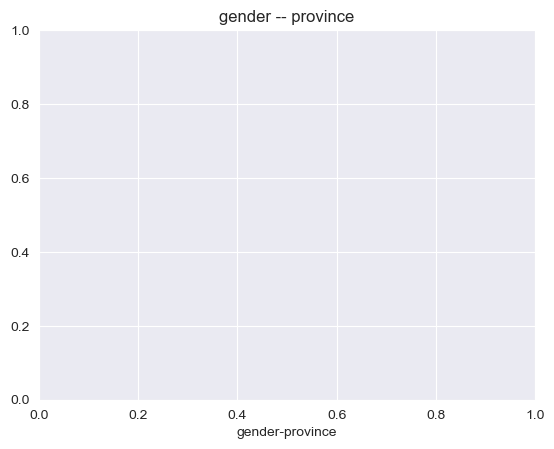

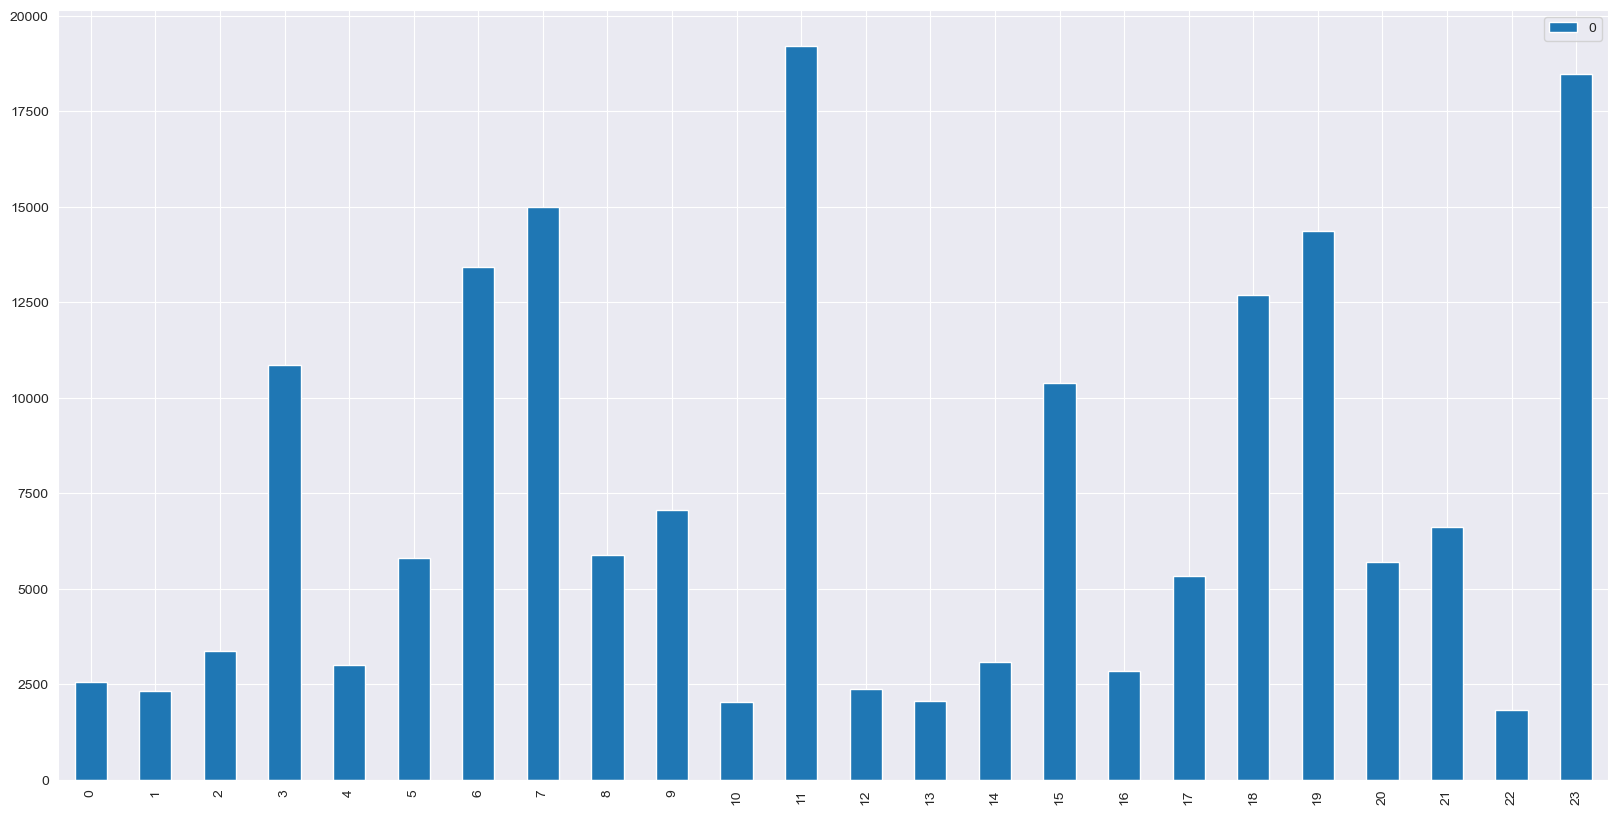

In [5]:

df_onizleme(df_customer_history)
df_onizleme(df_customer)

ikili_karsilastirma(df_customer,'gender','province',1)

In [6]:
#date verisini object -> datetime yapma
df_customer_history["date"] = pd.to_datetime(df_customer_history["date"])
df_referance["ref_date"] = pd.to_datetime(df_referance["ref_date"])
df_referance_test["ref_date"] = pd.to_datetime(df_referance_test["ref_date"])

In [7]:
#df_customer_history eksik verilerin yerini 0 ile doldurma
df_customer_history["mobile_eft_all_cnt"] = df_customer_history["mobile_eft_all_cnt"].fillna(0)
df_customer_history["mobile_eft_all_amt"] = df_customer_history["mobile_eft_all_amt"].fillna(0)
df_customer_history["cc_transaction_all_amt"] = df_customer_history["cc_transaction_all_amt"].fillna(0)
df_customer_history["cc_transaction_all_cnt"] = df_customer_history["cc_transaction_all_cnt"].fillna(0)


In [8]:
#work_sector sütunundaki boş verileri doldurduk
df_customer["work_sector"]=df_customer["work_sector"].fillna("Unknown")

In [9]:
#MERGE İŞLEMLERİ
#df_customer,df_referance ve df_referance_test ile df_customer_history merge ettik
df_merge = df_customer.merge(df_customer_history,how = "inner",on = 'cust_id')
df_merge_train = df_merge.merge(df_referance,how = "inner",on = 'cust_id')
df_merge_test = df_merge.merge(df_referance_test,how = "inner",on = 'cust_id')

In [10]:
df_onizleme(df_merge_train)
df_onizleme(df_merge_test)

describe :  
             cust_id           age        tenure                           date  mobile_eft_all_cnt  active_product_category_nbr  mobile_eft_all_amt  cc_transaction_all_amt  cc_transaction_all_cnt                       ref_date         churn
count  3.660875e+06  3.660875e+06  3.660875e+06                        3660875        3.660875e+06                 3.660875e+06        3.660875e+06            3.660875e+06            3.660875e+06                        3660875  3.660875e+06
mean   1.000296e+05  4.363371e+01  1.353389e+02  2017-02-21 13:55:38.680835072        2.943226e+00                 2.685811e+00        4.843853e+02            5.189602e+02            1.943425e+01  2018-04-15 03:29:05.420424448  1.399062e-01
min    0.000000e+00  1.900000e+01  1.900000e+01            2016-01-01 00:00:00        0.000000e+00                 2.000000e+00        0.000000e+00            0.000000e+00            0.000000e+00            2017-07-01 00:00:00  0.000000e+00
25%    4.991900e+04  3

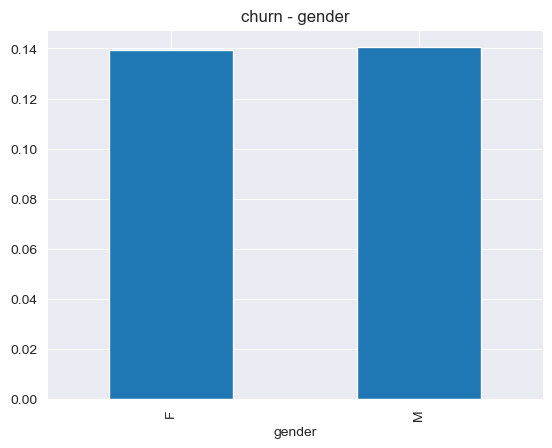

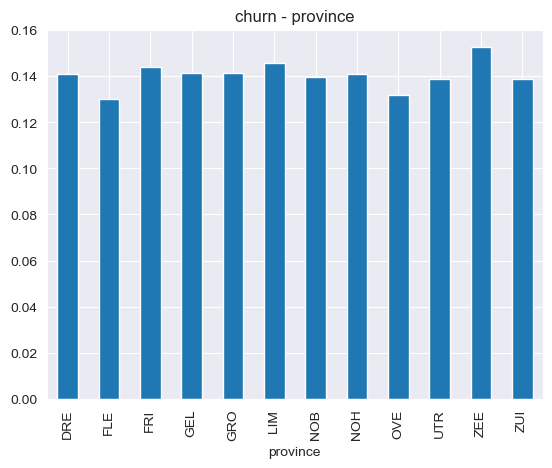

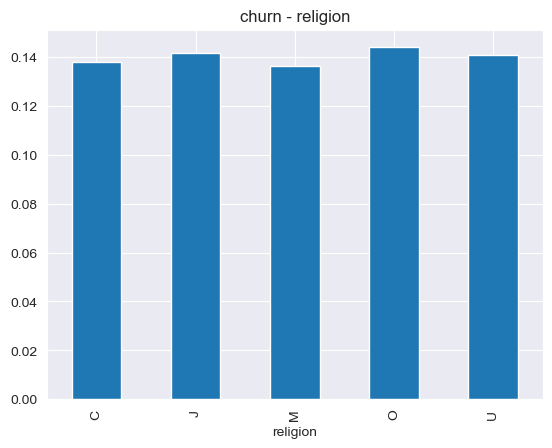

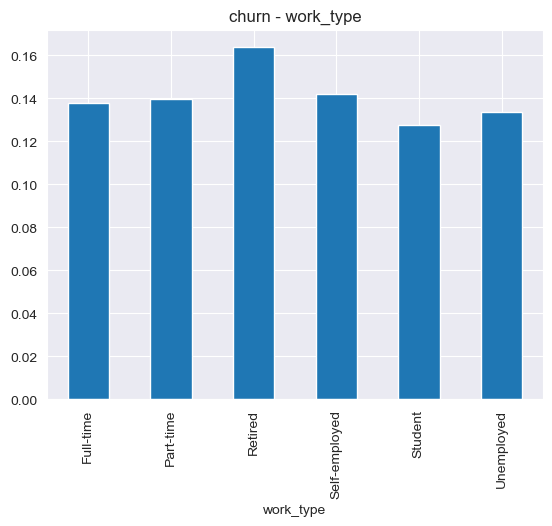

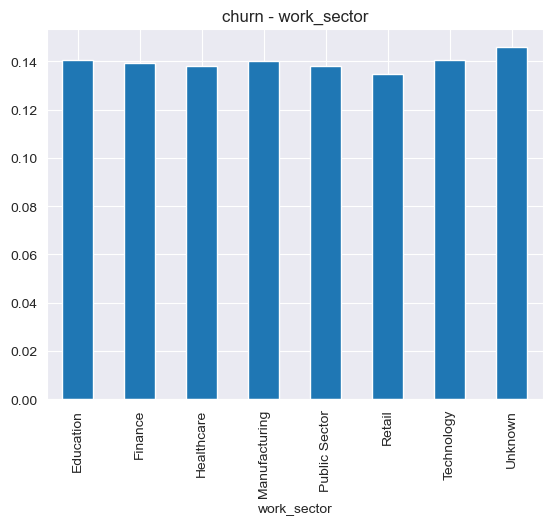

C:\Users\b_fur\AppData\Local\Temp\ipykernel_11328\2121394489.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  new_col = df.groupby(pd.cut(df[col],bins=60))["churn"].mean()


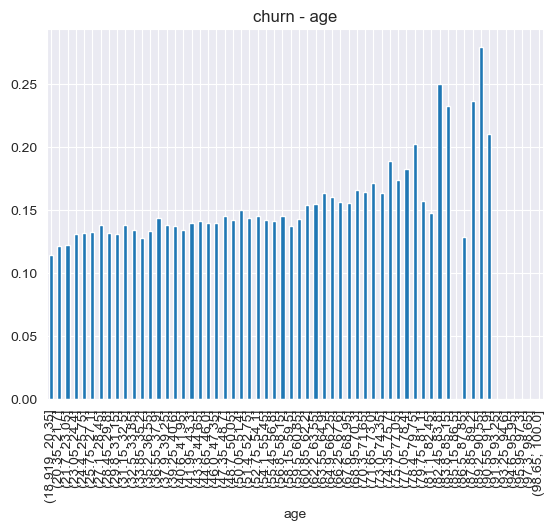

C:\Users\b_fur\AppData\Local\Temp\ipykernel_11328\2121394489.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  new_col = df.groupby(pd.cut(df[col],bins=60))["churn"].mean()


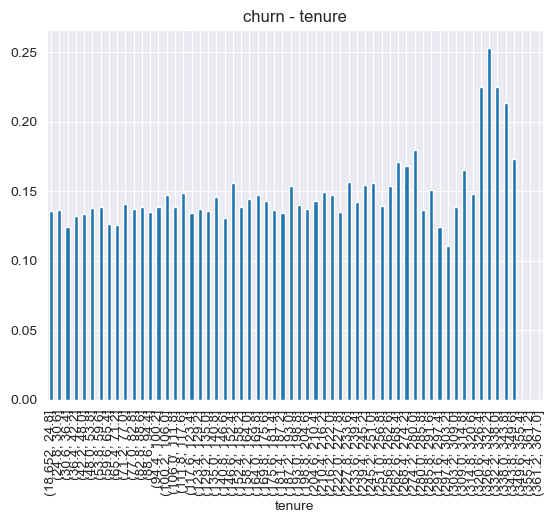

C:\Users\b_fur\AppData\Local\Temp\ipykernel_11328\2121394489.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  new_col = df.groupby(pd.cut(df[col],bins=60))["churn"].mean()


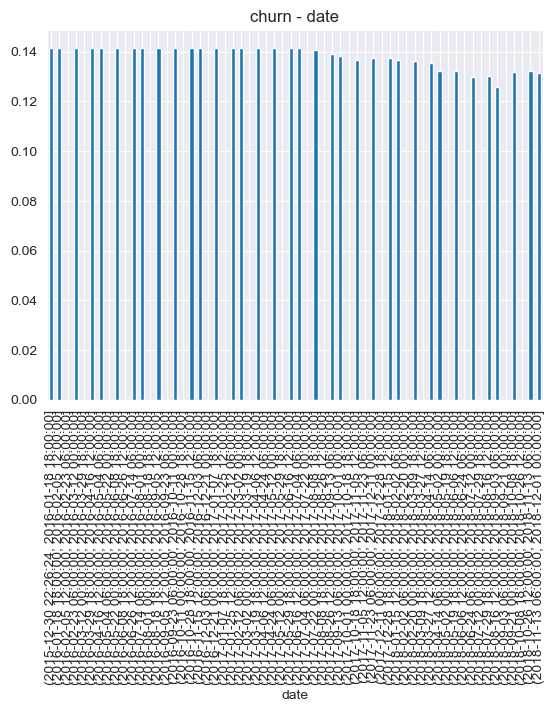

C:\Users\b_fur\AppData\Local\Temp\ipykernel_11328\2121394489.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  new_col = df.groupby(pd.cut(df[col],bins=60))["churn"].mean()


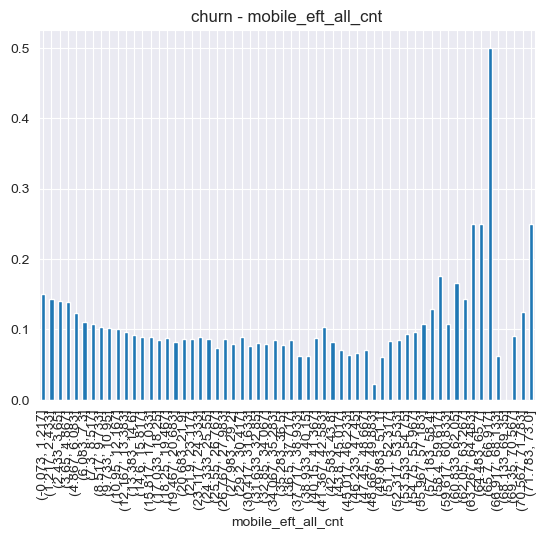

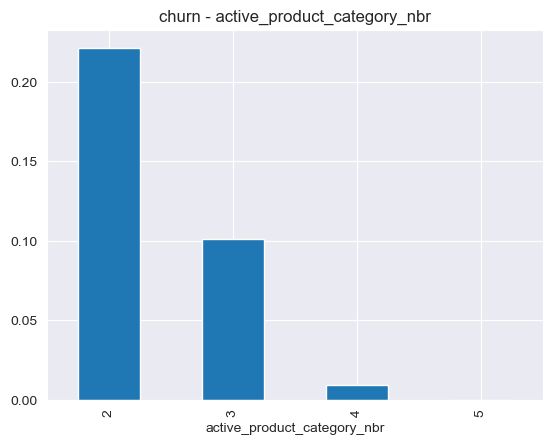

C:\Users\b_fur\AppData\Local\Temp\ipykernel_11328\2121394489.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  new_col = df.groupby(pd.cut(df[col],bins=60))["churn"].mean()


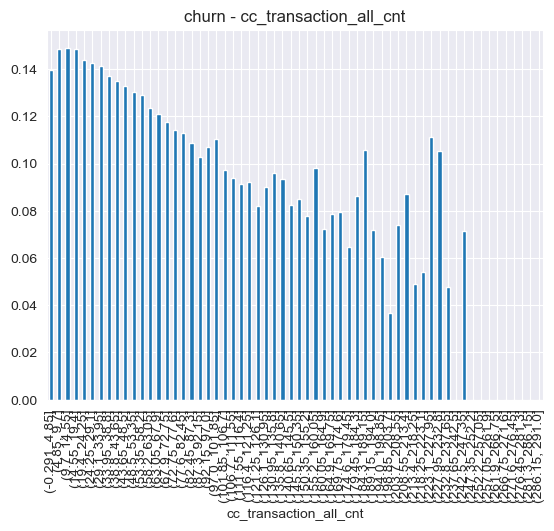

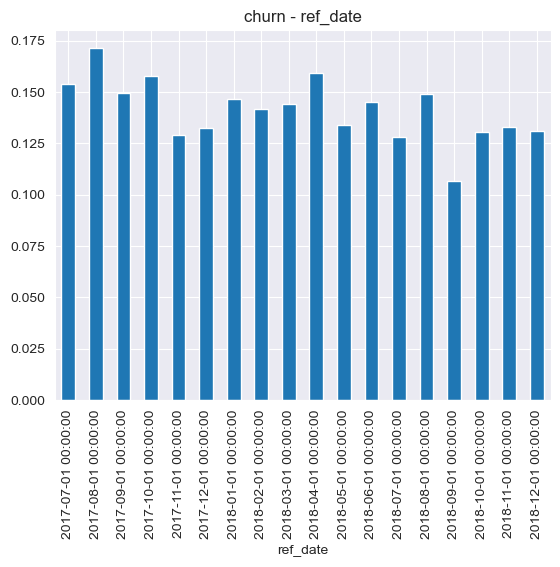

In [11]:
#VERİ ANALİZİ VE GÖRSELLEŞTİRME

#kategorik ve numeric değerlerin churn dağılımı
categorical_col_churn_analysis(df_merge_train)
numerical_col_churn_analysis(df_merge_train) #tenure değerini son 50-60 verisi churn değeri yüksek

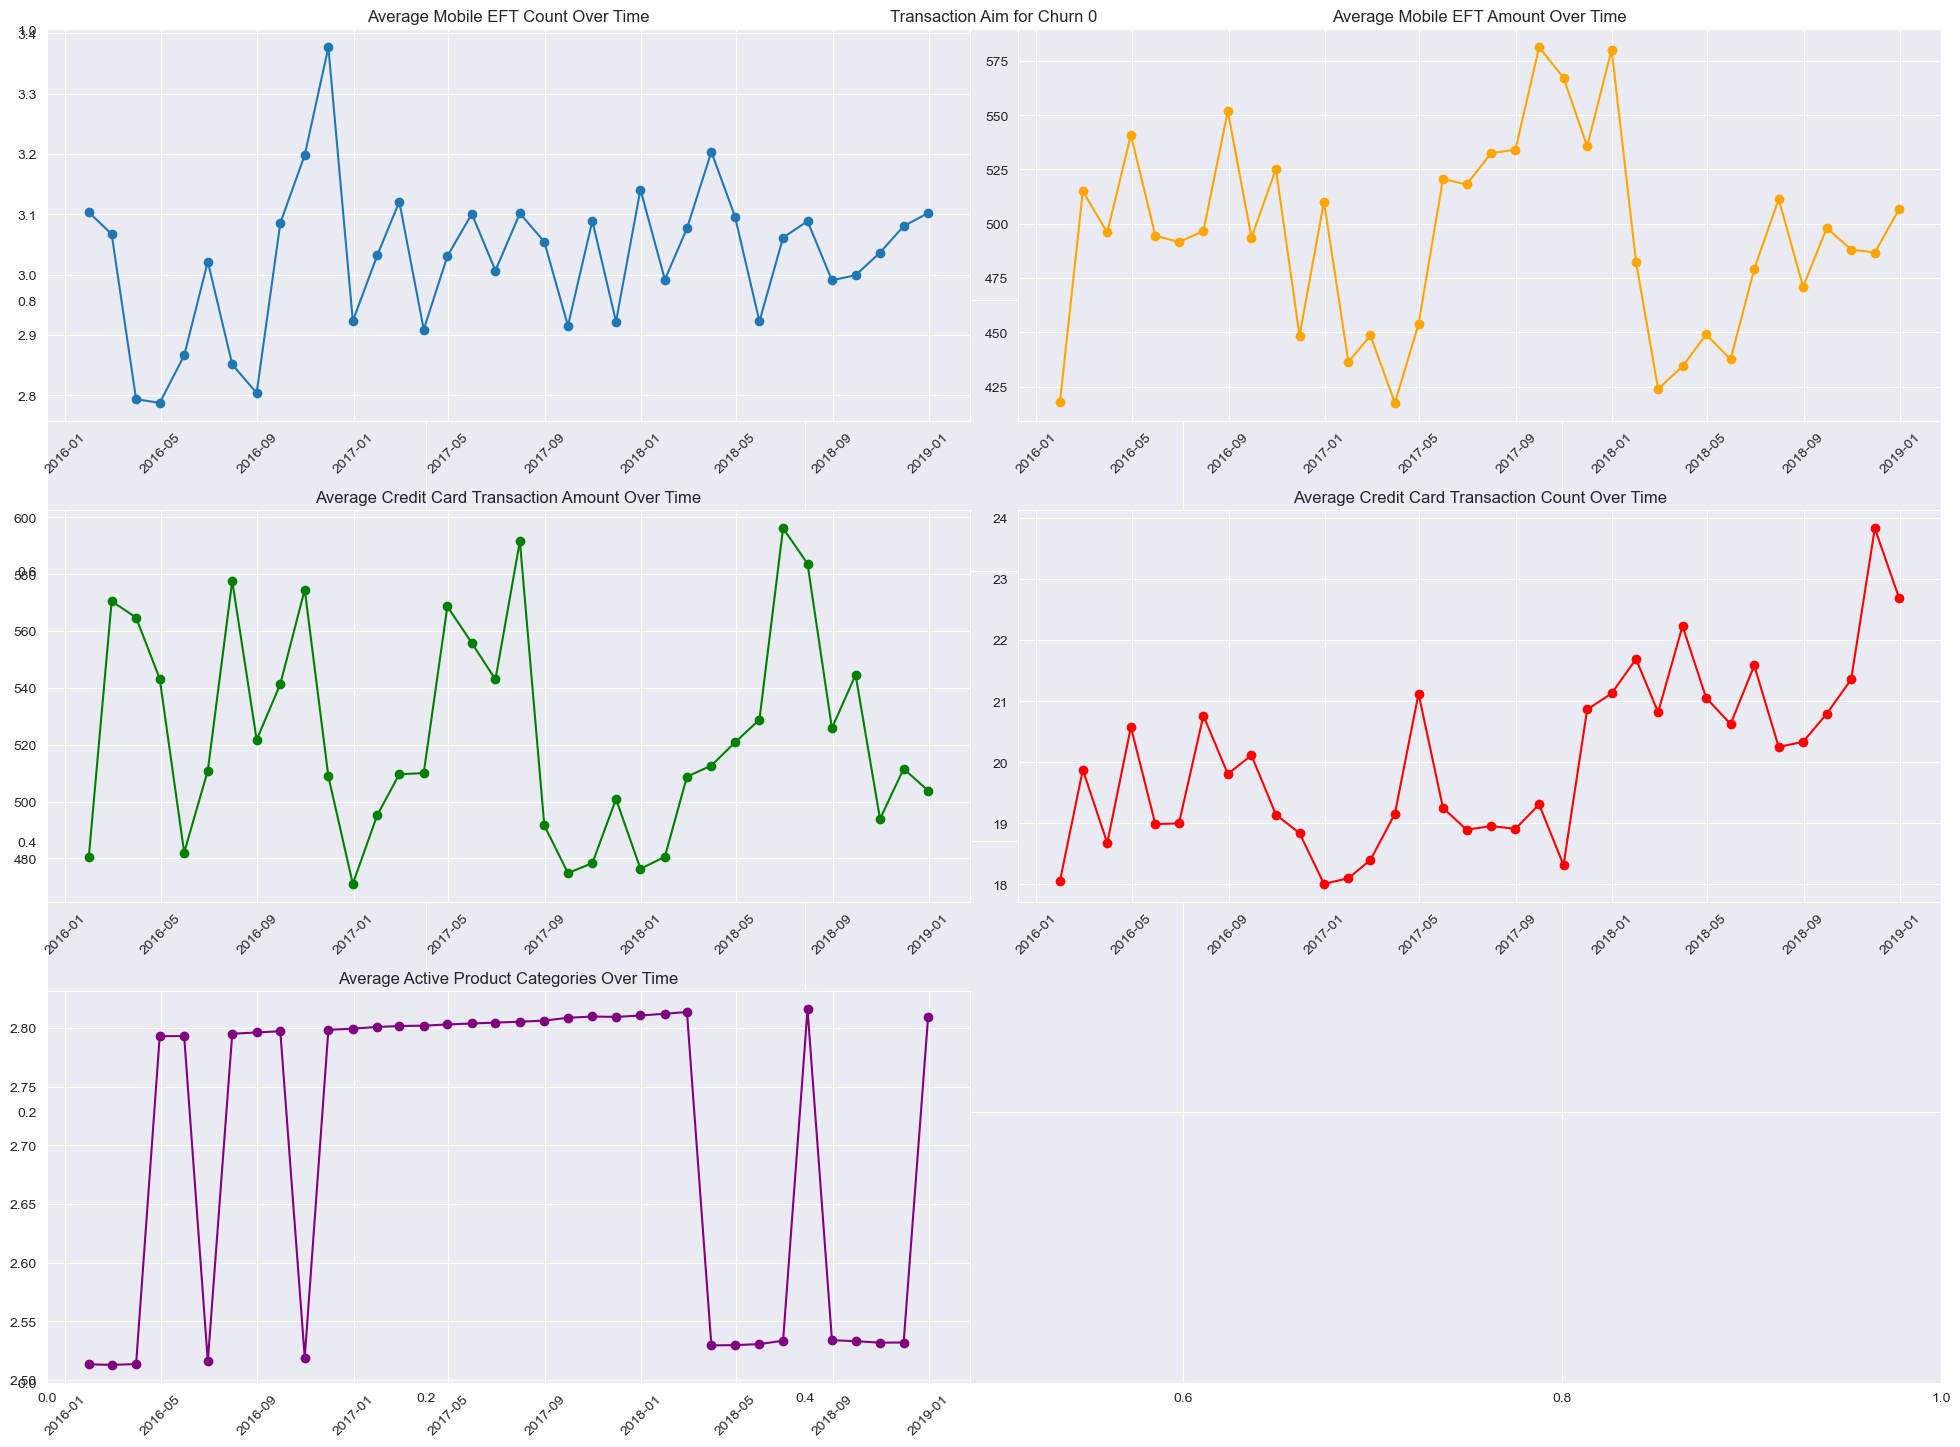

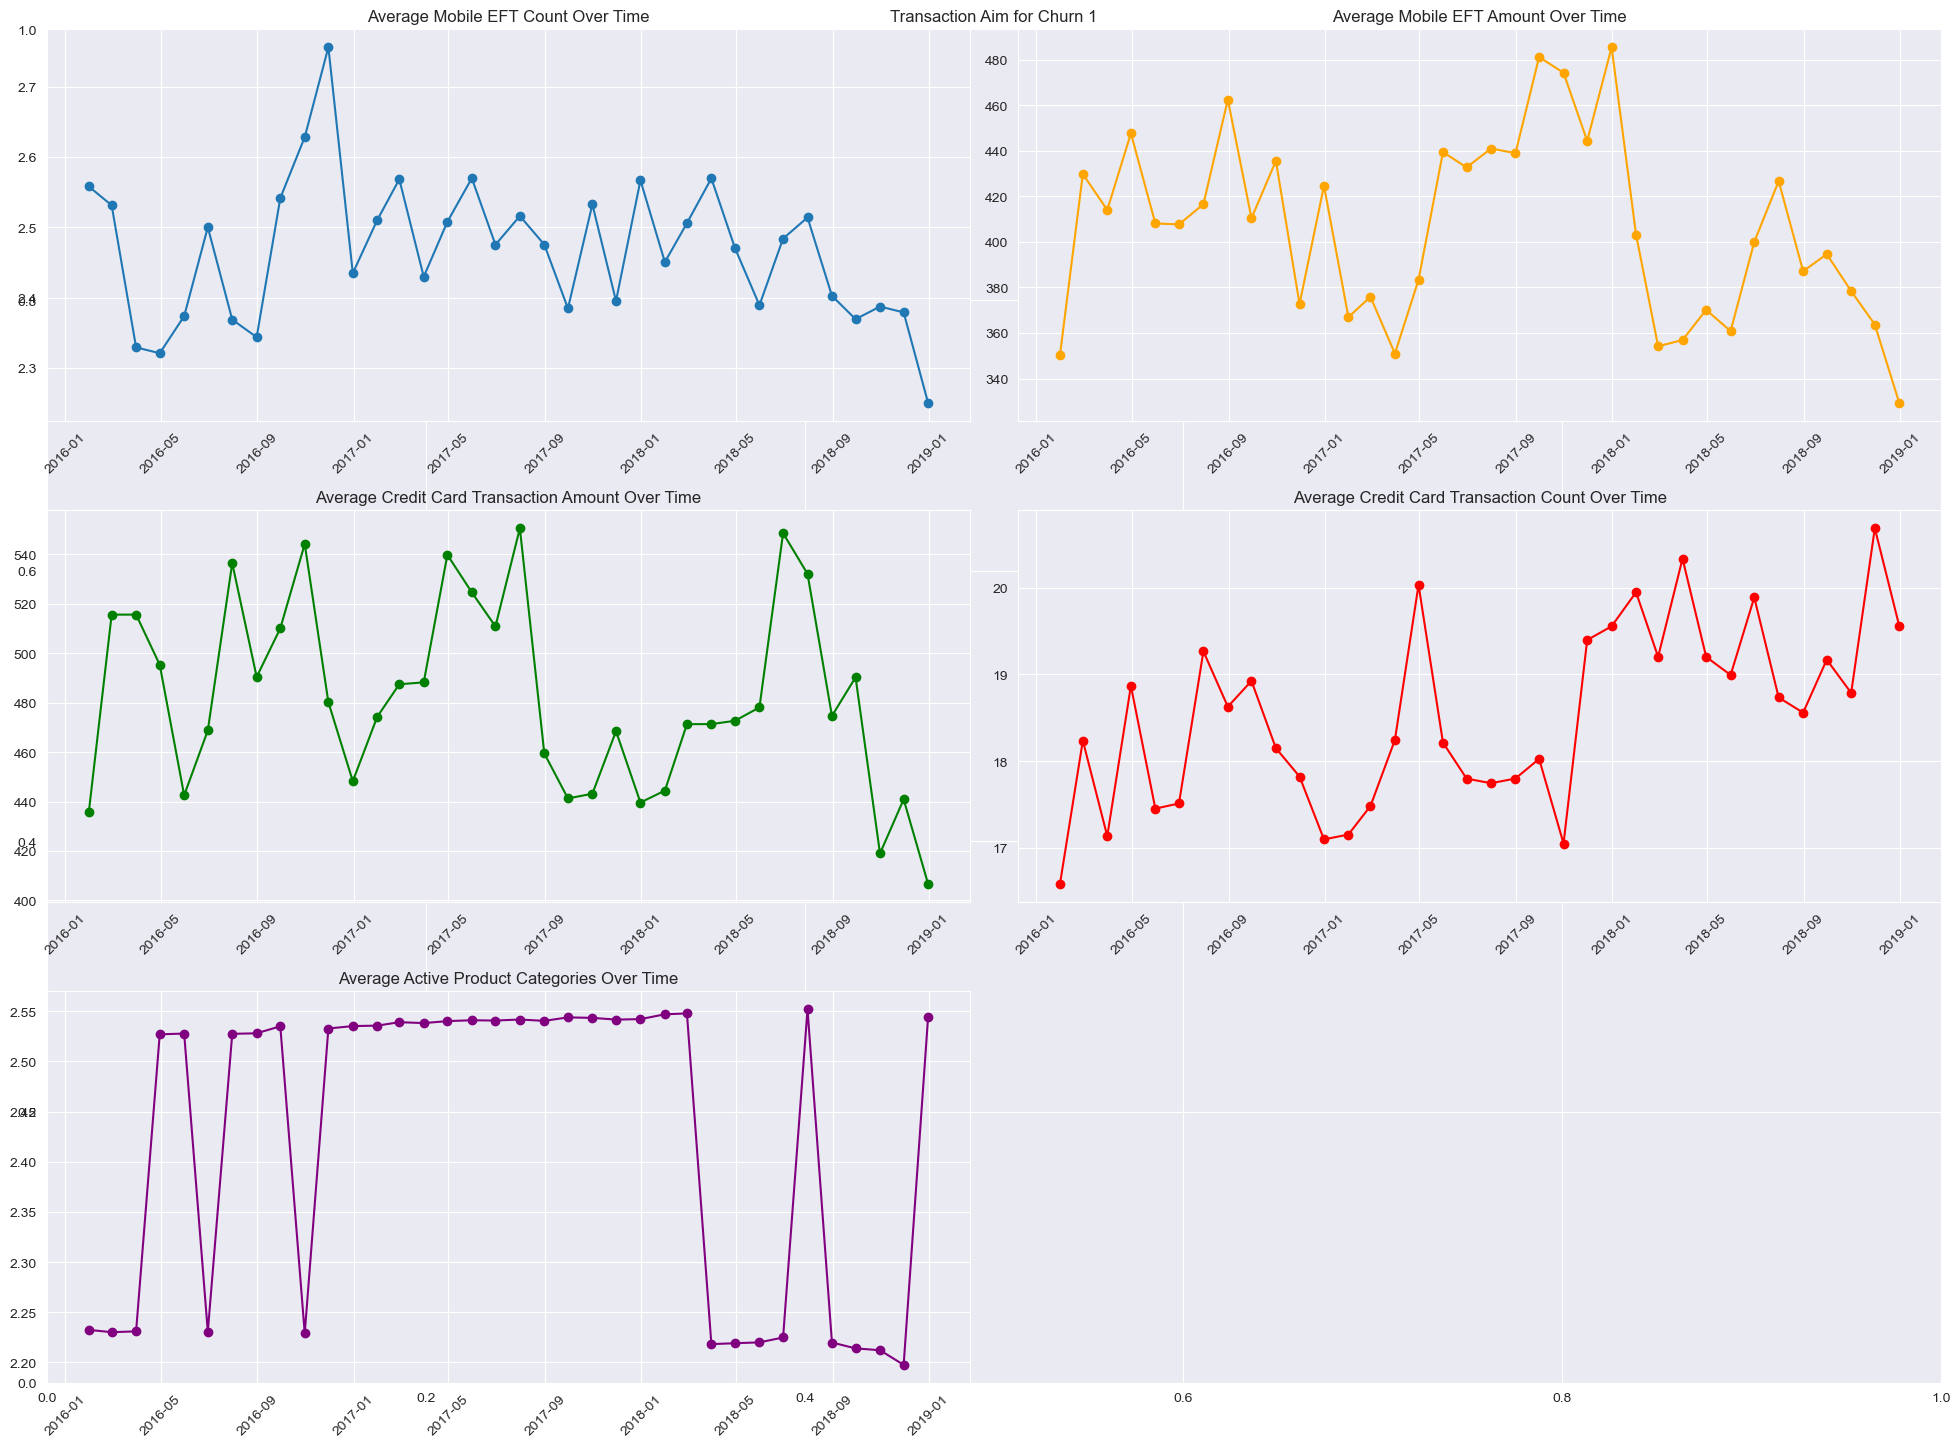

In [12]:

transaction_aim_for_churn_0(df_merge_train,0)
transaction_aim_for_churn_0(df_merge_train,1)

In [14]:
#FETAURE ENGİNEERİNG


print("--- Feature Engineering Başlıyor ---")

# 1. Tenure Oranlarını Hesapla
print("Tenure oranları hesaplanıyor...")
tenure_ratio_train = harcama_tenure_oranı(df_merge_train)
tenure_ratio_test = harcama_tenure_oranı(df_merge_test)

# 2. Aralıksız Sıfır İşlem Sayılarını Hesapla
print("Aralıksız sıfır işlem sayıları hesaplanıyor")
cons_zero_tran_train = consecutive_zero_transection_count(df_merge_train)
cons_zero_tran_test = consecutive_zero_transection_count(df_merge_test)

# 3. Farklı Zaman Pencereleri için Özellikleri Hesapla
print("\nZaman Pencereleri için Özellikler Hesaplanıyor")
# Eğitim Verisi
features_train_last_3m = monthly_numerical_analysis(df_merge_train, start_month=0, end_month=3, suffix='_last_3m')
features_train_lag_3m_to_6m = monthly_numerical_analysis(df_merge_train, start_month=3, end_month=6,
                                                         suffix='_lag_3m_to_6m')
features_train_last_6m = monthly_numerical_analysis(df_merge_train, start_month=0, end_month=6, suffix='_last_6m')
features_train_lag_6m_to_12m = monthly_numerical_analysis(df_merge_train, start_month=6, end_month=12,
                                                          suffix='_lag_6m_to_12m')
features_train_last_12m = monthly_numerical_analysis(df_merge_train, start_month=0, end_month=12, suffix='_last_12m')
# Test Verisi
features_test_last_3m = monthly_numerical_analysis(df_merge_test, start_month=0, end_month=3, suffix='_last_3m')
features_test_lag_3m_to_6m = monthly_numerical_analysis(df_merge_test, start_month=3, end_month=6,
                                                        suffix='_lag_3m_to_6m')
features_test_last_6m = monthly_numerical_analysis(df_merge_test, start_month=0, end_month=6, suffix='_last_6m')
features_test_lag_6m_to_12m = monthly_numerical_analysis(df_merge_test, start_month=6, end_month=12,
                                                         suffix='_lag_6m_to_12m')
features_test_last_12m = monthly_numerical_analysis(df_merge_test, start_month=0, end_month=12, suffix='_last_12m')

--- Feature Engineering Başlıyor ---
Tenure oranları hesaplanıyor...
Aralıksız sıfır işlem sayıları hesaplanıyor

Zaman Pencereleri için Özellikler Hesaplanıyor


In [15]:
# 4. Kategorik Değişkenleri Hazırla (One-Hot Encoding)
print("\nKategorik değişkenler için One-Hot Encoding yapılıyor")
cat_cols = ["gender", "province", "religion", "work_type", "work_sector"]
df_get_dummies = pd.get_dummies(df_customer, columns=cat_cols, drop_first=True)


Kategorik değişkenler için One-Hot Encoding yapılıyor


In [16]:
# TÜM ÖZELLİKLERİ BİRLEŞTİRME (MERGE)

# Temel DataFrame'leri Oluştur
df_train_base = pd.merge(df_referance, df_get_dummies, on='cust_id', how='left')
df_test_base = pd.merge(df_referance_test, df_get_dummies, on='cust_id', how='left')

# Eğitim Seti İçin Merge Listesi
features_to_merge_train = [
    (tenure_ratio_train, 'cust_id'),
    (cons_zero_tran_train, 'cust_id'),
    (features_train_last_3m, ['cust_id', 'ref_date']),
    (features_train_lag_3m_to_6m, ['cust_id', 'ref_date']),
    (features_train_last_6m, ['cust_id', 'ref_date']),
    (features_train_lag_6m_to_12m, ['cust_id', 'ref_date']),
    (features_train_last_12m, ['cust_id', 'ref_date'])
]

# Test Seti İçin Merge Listesi
features_to_merge_test = [
    (tenure_ratio_test, 'cust_id'),
    (cons_zero_tran_test, 'cust_id'),
    (features_test_last_3m, ['cust_id', 'ref_date']),
    (features_test_lag_3m_to_6m, ['cust_id', 'ref_date']),
    (features_test_last_6m, ['cust_id', 'ref_date']),
    (features_test_lag_6m_to_12m, ['cust_id', 'ref_date']),
    (features_test_last_12m, ['cust_id', 'ref_date'])
]

# Eğitim Setini Birleştir
final_data_train = df_train_base.copy()
print("Eğitim seti özellikleri birleştiriliyor")
for df_feature, key in features_to_merge_train:
    if df_feature is not None and not df_feature.empty:
        # Anahtar olmayan sütunlarda çakışma kontrolü (opsiyonel ama faydalı)
        # existing_cols = set(final_data_train.columns); new_cols = set(df_feature.columns)
        # key_cols = set([key] if isinstance(key, str) else key); overlap = (existing_cols & new_cols) - key_cols
        # if overlap: print(f"Uyarı: Çakışma - {overlap}")
        final_data_train = pd.merge(final_data_train, df_feature, on=key, how='left')
    else:
        print(f"Uyarı: Bir özellik DataFrame'i boş olduğu için merge atlandı (Train). Anahtar: {key}")

# Test Setini Birleştir
final_data_test = df_test_base.copy()
print("\nTest seti özellikleri birleştiriliyor")
for df_feature, key in features_to_merge_test:
    if df_feature is not None and not df_feature.empty:
        final_data_test = pd.merge(final_data_test, df_feature, on=key, how='left')
    else:
        print(f"Uyarı: Bir özellik DataFrame'i boş olduğu için merge atlandı (Test). Anahtar: {key}")

print(f"\nEğitim Seti Son Boyut (Birleştirme Sonrası): {final_data_train.shape}")
print(f"Test Seti Son Boyut (Birleştirme Sonrası): {final_data_test.shape}")

Eğitim seti özellikleri birleştiriliyor...

Test seti özellikleri birleştiriliyor...

Eğitim Seti Son Boyut (Birleştirme Sonrası): (133287, 212)
Test Seti Son Boyut (Birleştirme Sonrası): (43006, 211)


In [17]:
# Belleği Temizle
del features_train_last_3m, features_train_lag_3m_to_6m, features_train_last_6m, features_train_lag_6m_to_12m, features_train_last_12m
del features_test_last_3m, features_test_lag_3m_to_6m, features_test_last_6m, features_test_lag_6m_to_12m, features_test_last_12m
del tenure_ratio_train, tenure_ratio_test, cons_zero_tran_train, cons_zero_tran_test, df_get_dummies
del df_train_base, df_test_base, df_merge_train, df_merge_test, df_merge  # Artık bunlara ihtiyaç yok
gc.collect()

42

In [18]:
# 1. NaN Değerleri Doldurma (Merge Sonrası Oluşanlar)
print("Adım 1: NaN Değerleri Doldurma...")
# Doldurulacak sütunları daha dinamik bulalım (ID, ref_date, churn ve dummy olmayanlar)
base_cols = ['cust_id', 'ref_date', 'churn']
dummy_cols = [col for col in final_data_train.columns if
              '_' in col and col.split('_')[0] in cat_cols]  # cat_cols'u tekrar kullan
feature_cols_to_fill_train = [col for col in final_data_train.columns if col not in base_cols and col not in dummy_cols]
feature_cols_to_fill_test = [col for col in final_data_test.columns if col not in base_cols and col not in dummy_cols]

final_data_train[feature_cols_to_fill_train] = final_data_train[feature_cols_to_fill_train].fillna(0)
final_data_test[feature_cols_to_fill_test] = final_data_test[feature_cols_to_fill_test].fillna(0)
print("NaN doldurma tamamlandı.")

Adım 1: NaN Değerleri Doldurma...
NaN doldurma tamamlandı.


In [19]:
# 2. Delta ve Yüzdesel Değişim Özelliklerini Hesapla
final_data_train = calculate_delta_pct_features(final_data_train)
final_data_test = calculate_delta_pct_features(final_data_test)


Değişim Özellikleri Hesaplanıyor...
50 Delta ve 50 Yüzdesel Değişim özelliği eklendi.

Değişim Özellikleri Hesaplanıyor...
50 Delta ve 50 Yüzdesel Değişim özelliği eklendi.


C:\Users\b_fur\AppData\Local\Temp\ipykernel_11328\2121394489.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_out[pct_col_name] = (current - lagged) / (lagged + epsilon)
C:\Users\b_fur\AppData\Local\Temp\ipykernel_11328\2121394489.py:340: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_out[delta_col_name] = current - lagged
C:\Users\b_fur\AppData\Local\Temp\ipykernel_11328\2121394489.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

In [20]:
# 3. Çarpıklık Düzeltme (Log Dönüşümü)
print("\nAdım 3: Çarpıklık Kontrolü ve Düzeltme...")
# Çarpıklığı kontrol edilecek sütunları yeniden belirle (yeni delta/pct sütunları dahil)
key_cols_train = ['cust_id', 'ref_date', 'churn']
dummy_cols = [col for col in final_data_train.columns if '_' in col and col.split('_')[0] in cat_cols]
cols_to_check_skew = [col for col in final_data_train.columns if
                      col not in key_cols_train and
                      col not in dummy_cols and
                      final_data_train[col].dtype in [np.int64, np.float64, np.int32, np.float32]]
skewness = final_data_train[cols_to_check_skew].skew()
print("En Yüksek Pozitif Çarpıklık (Top 15):")
print(skewness.sort_values(ascending=False).head(15))

cols_to_log_transform = skewness[skewness > 1].index.tolist()  # Sadece pozitif çarpıklık > 1
print(f"\n{len(cols_to_log_transform)} sütuna log dönüşümü uygulanacak.")


Adım 3: Çarpıklık Kontrolü ve Düzeltme...
En Yüksek Pozitif Çarpıklık (Top 15):
pct_change_cc_transaction_all_amt_min_last_6m_vs_lag_6m_to_12m     120.913546
pct_change_cc_transaction_all_amt_last_last_6m_vs_lag_6m_to_12m     68.299945
pct_change_cc_transaction_all_amt_max_last_6m_vs_lag_6m_to_12m      61.718910
pct_change_cc_transaction_all_amt_max_last_3m_vs_lag_3m_to_6m       46.590480
pct_change_cc_transaction_all_cnt_max_last_6m_vs_lag_6m_to_12m      37.700974
pct_change_mobile_eft_all_amt_mean_last_6m_vs_lag_6m_to_12m         35.577549
pct_change_mobile_eft_all_amt_sum_last_6m_vs_lag_6m_to_12m          35.577547
pct_change_cc_transaction_all_amt_last_last_3m_vs_lag_3m_to_6m      34.771333
pct_change_mobile_eft_all_amt_max_last_6m_vs_lag_6m_to_12m          33.974576
pct_change_cc_transaction_all_amt_mean_last_6m_vs_lag_6m_to_12m     32.995236
pct_change_cc_transaction_all_amt_sum_last_6m_vs_lag_6m_to_12m      32.995233
pct_change_cc_transaction_all_amt_mean_last_3m_vs_lag_3m_to_6

In [21]:

for col in cols_to_log_transform:
    final_data_train[col] = np.log1p(final_data_train[col])
    if col in final_data_test.columns:
        final_data_test[col] = np.log1p(final_data_test[col])
print("Logaritmik dönüşüm tamamlandı.")

Logaritmik dönüşüm tamamlandı.


In [22]:
temp_X_train_for_corr = final_data_train.drop(columns=['cust_id', 'ref_date', 'churn'])
corr_matrix = temp_X_train_for_corr.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] == 1)]

if to_drop_corr:
    print(f"Korelasyonu tam 1 olan {len(to_drop_corr)} sütun bulundu ve çıkarılacak:")
    print(to_drop_corr)
    final_data_train = final_data_train.drop(columns=to_drop_corr)
    # Test setinden de çıkaralım (varsa)
    cols_to_drop_in_test_corr = [col for col in to_drop_corr if col in final_data_test.columns]
    final_data_test = final_data_test.drop(columns=cols_to_drop_in_test_corr)
else:
    print("Korelasyonu tam 1 olan sütun bulunamadı.")
del temp_X_train_for_corr, corr_matrix, upper_tri  # Belleği temizle

Korelasyonu tam 1 olan 11 sütun bulundu ve çıkarılacak:
['tenure_y', 'mobile_eft_all_cnt_last_last_6m', 'active_product_category_nbr_last_last_6m', 'mobile_eft_all_amt_last_last_6m', 'cc_transaction_all_amt_last_last_6m', 'cc_transaction_all_cnt_last_last_6m', 'mobile_eft_all_cnt_last_last_12m', 'active_product_category_nbr_last_last_12m', 'mobile_eft_all_amt_last_last_12m', 'cc_transaction_all_amt_last_last_12m', 'cc_transaction_all_cnt_last_last_12m']


In [23]:

# 5. Özellik Ölçeklendirme (StandardScaler)
from sklearn.preprocessing import StandardScaler

print("\nAdım 4: Özellik Ölçeklendirme...")
key_cols_train = ['cust_id', 'ref_date', 'churn']  # Tekrar tanımla (korelasyon sonrası)
dummy_cols = [col for col in final_data_train.columns if '_' in col and col.split('_')[0] in cat_cols]  # Tekrar tanımla
cols_to_scale = [col for col in final_data_train.columns if
                 col not in key_cols_train and
                 col not in dummy_cols and
                 final_data_train[col].dtype in [np.int64, np.float64, np.int32, np.float32]]
print(f"Ölçeklenecek {len(cols_to_scale)} sütun bulundu.")

scaler = StandardScaler()
# Scaler'ı SADECE eğitim verisine fit et
final_data_train[cols_to_scale] = scaler.fit_transform(final_data_train[cols_to_scale])

# Test verisine SADECE transform uygula
cols_to_scale_test = [col for col in cols_to_scale if
                      col in final_data_test.columns]  # Ölçeklenecek sütunlar testte var mı?
if cols_to_scale_test:
    final_data_test[cols_to_scale_test] = scaler.transform(final_data_test[cols_to_scale_test])
print("Özellik ölçeklendirme tamamlandı.")


Adım 4: Özellik Ölçeklendirme...
Ölçeklenecek 270 sütun bulundu.
Özellik ölçeklendirme tamamlandı.


In [24]:
# VERİYİ MODELLEME İÇİN AYIRMA (X, y)
print("\n--- Modelleme İçin Veri Ayırma ---")

cols_to_drop_model = ['cust_id', 'ref_date']

# y_train'i DOĞRU yerden (final_data_train) al
y_train = final_data_train['churn']

# X_train'i oluştururken churn'ü de çıkar
X_train = final_data_train.drop(columns=cols_to_drop_model + ['churn'])

# X_test'i oluştur
X_test = final_data_test.drop(columns=cols_to_drop_model)

# Sütun Hizalama (ÇOK ÖNEMLİ)
missing_cols_in_test = set(X_train.columns) - set(X_test.columns)
extra_cols_in_test = set(X_test.columns) - set(X_train.columns)

if missing_cols_in_test:
    print(f"Uyarı: Test setinde eksik sütunlar 0 ile dolduruluyor: {missing_cols_in_test}")
    for c in missing_cols_in_test: X_test[c] = 0
if extra_cols_in_test:
    print(f"Uyarı: Test setinde fazla sütunlar çıkarılıyor: {extra_cols_in_test}")
    X_test = X_test.drop(columns=list(extra_cols_in_test))

X_test = X_test[X_train.columns]  # Son sıra kontrolü

print("X ve y setleri oluşturuldu ve hizalandı.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
assert list(X_train.columns) == list(X_test.columns), "HATA: X_train ve X_test sütunları eşleşmiyor!"


--- Modelleme İçin Veri Ayırma ---
X ve y setleri oluşturuldu ve hizalandı.
X_train shape: (133287, 298)
y_train shape: (133287,)
X_test shape: (43006, 298)


In [25]:
# MODELLEME (Optuna, CV, Tahmin vb.)
corr_matrix=X_train.corr()
esik_deger = 0.9
corr_matrix_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) #matrixi üst üçgenini alıyoruz tekrarlılardan kurtulmak için
high_corr = corr_matrix_upper.stack()[corr_matrix_upper.stack().abs() > esik_deger]
high_corr = high_corr.reset_index()
high_corr.columns = ['degisken_1', 'degisken_2', 'Korelasyon']

print(high_corr[high_corr["degisken_1"] != high_corr["degisken_2"]].sort_values(by="Korelasyon",ascending=False))

                                            degisken_1                                         degisken_2  Korelasyon
763  pct_change_active_product_category_nbr_mean_la...  pct_change_active_product_category_nbr_sum_las...    1.000000
799  delta_cc_transaction_all_amt_mean_last_6m_vs_l...  delta_cc_transaction_all_amt_sum_last_6m_vs_la...    1.000000
827  delta_cc_transaction_all_cnt_mean_last_3m_vs_l...  delta_cc_transaction_all_cnt_sum_last_3m_vs_la...    1.000000
475           active_product_category_nbr_mean_last_6m            active_product_category_nbr_sum_last_6m    1.000000
734  delta_mobile_eft_all_cnt_mean_last_6m_vs_lag_6...  delta_mobile_eft_all_cnt_sum_last_6m_vs_lag_6m...    1.000000
..                                                 ...                                                ...         ...
728  delta_mobile_eft_all_cnt_mean_last_3m_vs_lag_3...  delta_mobile_eft_all_cnt_max_last_3m_vs_lag_3m...    0.900437
40                      mobile_eft_all_cnt_min_last_3m  

In [26]:
def recall_at_k(y_true, y_prob, k=0.1):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    m = max(1, int(np.round(k * n)))
    order = np.argsort(-y_prob, kind="mergesort")
    top = order[:m]

    tp_at_k = y_true[top].sum()
    P = y_true.sum()

    return float(tp_at_k / P) if P > 0 else 0.0


def lift_at_k(y_true, y_prob, k=0.1):
    """
    Tahmin edilen olasılıkların en üst k%'sını pozitif etiketleyerek lift (precision/prevalence) değerini hesaplar.

    Parametreler:
        y_true (list): Gerçek ikili etiketler.
        y_prob (list): Tahmin edilen olasılıklar.
        k (float): Pozitif etiketlenecek olasılıkların yüzdelik dilimi (varsayılan 0.1).

    Döndürür:
        float: En iyi k% tahminlerindeki lift değeri.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    m = max(1, int(np.round(k * n)))
    order = np.argsort(-y_prob, kind="mergesort")
    top = order[:m]

    tp_at_k = y_true[top].sum()
    precision_at_k = tp_at_k / m
    prevalence = y_true.mean()

    return float(precision_at_k / prevalence) if prevalence > 0 else 0.0


def convert_auc_to_gini(auc):
    """
    ROC AUC skorunu Gini katsayısına dönüştürür.

    Gini katsayısı, ROC AUC skorunun doğrusal bir dönüşümüdür.

    Parametreler:
        auc (float): ROC AUC skoru (0 ile 1 arasında).

    Döndürür:
        float: Gini katsayısı (-1 ile 1 arasında).
    """
    return 2 * auc - 1


def ing_hubs_datathon_metric(y_true, y_prob):
    """
    Gini, recall@10% ve lift@10% metriklerini birleştiren özel bir metrik hesaplar.

    Metrik, her bir skoru bir baseline modelin metrik değerlerine göre oranlar ve aşağıdaki ağırlıkları uygular:
    - Gini: %40
    - Recall@10%: %30
    - Lift@10%: %30

    Parametreler:
        y_true (list): Gerçek ikili etiketler.
        y_prob (list): Tahmin edilen olasılıklar.

    Döndürür:
        float: Ağırlıklandırılmış bileşik skor.
    """
    # final metrik için ağırlıklar
    score_weights = {
        "gini": 0.4,
        "recall_at_10perc": 0.3,
        "lift_at_10perc": 0.3,
    }

    # baseline modelin her bir metrik için değerleri
    baseline_scores = {
        "roc_auc": 0.6925726757936908,
        "recall_at_10perc": 0.18469015795868773,
        "lift_at_10perc": 1.847159286784029,
    }

    # y_prob tahminleri için metriklerin hesaplanması
    roc_auc = roc_auc_score(y_true, y_prob)
    recall_at_10perc = recall_at_k(y_true, y_prob, k=0.1)
    lift_at_10perc = lift_at_k(y_true, y_prob, k=0.1)

    new_scores = {
        "roc_auc": roc_auc,
        "recall_at_10perc": recall_at_10perc,
        "lift_at_10perc": lift_at_10perc,
    }

    # roc auc değerlerinin gini değerine dönüştürülmesi
    baseline_scores["gini"] = convert_auc_to_gini(baseline_scores["roc_auc"])
    new_scores["gini"] = convert_auc_to_gini(new_scores["roc_auc"])

    # baseline modeline oranlama
    final_gini_score = new_scores["gini"] / baseline_scores["gini"]
    final_recall_score = new_scores["recall_at_10perc"] / baseline_scores["recall_at_10perc"]
    final_lift_score = new_scores["lift_at_10perc"] / baseline_scores["lift_at_10perc"]

    # ağırlıklandırılmış metriğin hesaplanması
    final_score = (
        final_gini_score * score_weights["gini"] +
        final_recall_score * score_weights["recall_at_10perc"] +
        final_lift_score * score_weights["lift_at_10perc"]
    )
    return final_score



In [27]:
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import gc  # Bellek yönetimi için
import optuna

try:
    df_referance_test = pd.read_csv("referance_data_test.csv")
except FileNotFoundError:
    print("HATA: referance_data_test.csv bulunamadı!")
    exit()

print(f"Modelleme için X_train shape: {X_train.shape}")
print(f"Modelleme için y_train shape: {y_train.shape}")
print(f"Modelleme için X_test shape: {X_test.shape}")

Modelleme için X_train shape: (133287, 298)
Modelleme için y_train shape: (133287,)
Modelleme için X_test shape: (43006, 298)


In [28]:
def objective_lgbm(trial):
    params = {
        'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt',
        'random_state': 42, 'n_jobs': -1,
        'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0,
        'is_unbalance': trial.suggest_categorical('is_unbalance', [True, False]),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 800, 2500, step=100),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 0, 10)
    }

    N_FOLDS_OPT = 5
    # DÜZELTME: random_state'i sabit tutalım
    skf_opt = StratifiedKFold(n_splits=N_FOLDS_OPT, shuffle=True, random_state=42)
    oof_preds_opt = np.zeros(X_train.shape[0])
    for fold, (train_idx, val_idx) in enumerate(skf_opt.split(X_train, y_train)):
        # ... (CV döngüsü öncekiyle aynı) ...
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train_fold, y_train_fold,
                  eval_set=[(X_val_fold, y_val_fold)],
                  eval_metric='auc',
                  callbacks=[lgb.early_stopping(50, verbose=False)])
        val_preds_proba = model.predict_proba(X_val_fold)[:, 1]
        if np.isnan(val_preds_proba).any(): return 0.0
        oof_preds_opt[val_idx] = val_preds_proba
        del X_train_fold, X_val_fold, y_train_fold, y_val_fold, model
        gc.collect()
    if np.isnan(oof_preds_opt).any(): return 0.0
    score = ing_hubs_datathon_metric(y_train, oof_preds_opt)
    return score



In [30]:
# ----- Optimizasyon Çalışmasını Başlat (LGBM) -----
study_lgbm = optuna.create_study(direction='maximize', study_name='LGBM Optimization')
N_TRIALS_LGBM = 50  # Deneme sayısı
print(f"\n--- Optuna LightGBM Optimizasyonu Başlıyor ({N_TRIALS_LGBM} deneme) ---")
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS_LGBM)

# ----- Sonuçları Değerlendir (LGBM) -----
print("\n--- LightGBM Optimizasyon Tamamlandı ---")
best_score_lgbm = study_lgbm.best_value
best_params_lgbm = study_lgbm.best_params
print(f"En İyi Deneme Skoru (Özel Metrik): {best_score_lgbm:.5f}")
print("En İyi Parametreler (LGBM):")
print(best_params_lgbm)

[I 2026-01-28 13:47:49,096] A new study created in memory with name: LGBM Optimization
[W 2026-01-28 13:47:49,133] Trial 0 failed with parameters: {'is_unbalance': True, 'learning_rate': 0.076543728175452, 'n_estimators': 800, 'num_leaves': 141, 'max_depth': 6, 'min_child_samples': 61, 'reg_alpha': 0.19592359938721293, 'reg_lambda': 0.09667858684872471, 'colsample_bytree': 0.687802520897195, 'subsample': 0.9633035460705524, 'subsample_freq': 1} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\b_fur\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\b_fur\AppData\Local\Temp\ipykernel_11328\1757675664.py", line 25, in objective_lgbm
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
                               ~~~~~~~~~~~~^^^^^^^^^^^
  File "C:\Users\b_fur\anaconda3\Lib\site-packages\pandas\


--- Optuna LightGBM Optimizasyonu Başlıyor (50 deneme) ---



KeyboardInterrupt



In [31]:
#(Karşılaştırma ve baseline geçme kontrolü önceki kodda olduğu gibi) ...

# ----- XGBoost için Optuna Objective Fonksiyonu -----
def objective_xgb(trial):
    params = {
        'objective': 'binary:logistic', 'eval_metric': 'auc',
        'use_label_encoder': False, 'random_state': 42, 'nthread': -1,
        #'tree_method':'gpu_hist', 'gpu_id': 0,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 800, 2500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'early_stopping_rounds' : 50

    }
    N_FOLDS_OPT = 5
    # DÜZELTME: random_state'i sabit tutalım
    skf_opt = StratifiedKFold(n_splits=N_FOLDS_OPT, shuffle=True, random_state=42)
    oof_preds_opt = np.zeros(X_train.shape[0])
    for fold, (train_idx, val_idx) in enumerate(skf_opt.split(X_train, y_train)):
        # ... (CV döngüsü öncekiyle aynı) ...
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = xgb.XGBClassifier(**params)
        model.fit(X_train_fold, y_train_fold,
                  eval_set=[(X_val_fold, y_val_fold)],
                  verbose=False)
        val_preds_proba = model.predict_proba(X_val_fold)[:, 1]
        if np.isnan(val_preds_proba).any(): return 0.0
        oof_preds_opt[val_idx] = val_preds_proba
        del X_train_fold, X_val_fold, y_train_fold, y_val_fold, model
        gc.collect()
    if np.isnan(oof_preds_opt).any(): return 0.0
    score = ing_hubs_datathon_metric(y_train, oof_preds_opt)
    return score


In [32]:

# ----- XGBoost Optimizasyon Çalışmasını Başlat -----
study_xgb = optuna.create_study(direction='maximize', study_name='XGBoost Optimization')
N_TRIALS_XGB = 50  # Deneme sayısı
print(f"\n--- Optuna XGBoost Optimizasyonu Başlıyor ({N_TRIALS_XGB} deneme) ---")
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS_XGB)

# ----- Sonuçları Değerlendir (XGBoost) -----
print("\n--- XGBoost Optimizasyon Tamamlandı ---")
best_score_xgb = study_xgb.best_value
best_params_xgb = study_xgb.best_params
print(f"En İyi Deneme Skoru (Özel Metrik): {best_score_xgb:.5f}")
print("En İyi Parametreler (XGBoost):")
print(best_params_xgb)

# ----- MODEL SEÇİMİ -----
print(f"\n--- Model Karşılaştırma ve Seçim ---")
print(f"Optimize LGBM Skoru (Optuna OOF): {best_score_lgbm:.5f}")
print(f"Optimize XGBoost Skoru (Optuna OOF): {best_score_xgb:.5f}")

if best_score_xgb > best_score_lgbm:
    print("Optimize XGBoost daha iyi görünüyor. XGBoost parametreleri kullanılacak.")
    final_best_params = best_params_xgb
    final_model_type = 'XGBoost'
    # Final CV ve Tahminler için XGBoost kullanılacak
else:
    print("Optimize LightGBM daha iyi veya eşit görünüyor. LGBM parametreleri kullanılacak.")
    final_best_params = best_params_lgbm
    final_model_type = 'LightGBM'
    # Final CV ve Tahminler için LightGBM kullanılacak

# ----- EN İYİ MODEL İLE FİNAL ÇAPRAZ DOĞRULAMA -----

N_FOLDS_FINAL = 5
skf_final = StratifiedKFold(n_splits=N_FOLDS_FINAL, shuffle=True, random_state=123)  # Farklı RS

oof_predictions_final = np.zeros(X_train.shape[0])
cv_scores_final = []
feature_importances_final = pd.DataFrame(index=X_train.columns)  # Önemleri toplamak için
#test_predictions_final = np.zeros(X_test.shape[0])  # Test tahminlerini toplamak için (ortalama alacağız)
test_predictions_list = []

print(f"\n--- {final_model_type} ile {N_FOLDS_FINAL}-Kat Final Çapraz Doğrulama Başlıyor ---")
print("Kullanılacak Parametreler:")
print(final_best_params)

[I 2026-01-28 13:48:15,390] A new study created in memory with name: XGBoost Optimization



--- Optuna XGBoost Optimizasyonu Başlıyor (50 deneme) ---


C:\Users\b_fur\anaconda3\Lib\site-packages\xgboost\callback.py:386: UserWarning: [13:48:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
[W 2026-01-28 13:48:19,716] Trial 0 failed with parameters: {'learning_rate': 0.016434865677925754, 'n_estimators': 1000, 'max_depth': 9, 'subsample': 0.5359216278048524, 'colsample_bytree': 0.5284962699696629, 'gamma': 0.01497205473704161, 'reg_alpha': 5.436099176017822e-08, 'reg_lambda': 3.0928605357403555e-08, 'min_child_weight': 10} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\b_fur\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\b_fur\AppData\Local\Temp\ipykernel_11328\3237280182.py", line 30, in objective_xgb
    model.fit(X_train_fold, y_train_fo

KeyboardInterrupt: 

In [33]:
for fold, (train_index, val_index) in enumerate(skf_final.split(X_train, y_train)):
    print(f"\n===== Final Fold {fold + 1}/{N_FOLDS_FINAL} =====")
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Seçilen modele göre modeli başlat
    if final_model_type == 'LightGBM':
        model_final = lgb.LGBMClassifier(objective='binary', metric='auc', random_state=42, n_jobs=-1,
                                         **final_best_params)
        model_final.fit(X_train_fold, y_train_fold,
                        eval_set=[(X_val_fold, y_val_fold)],
                        eval_metric='auc',
                        callbacks=[lgb.early_stopping(100, verbose=False)])
    elif final_model_type == 'XGBoost':
        model_final = xgb.XGBClassifier(objective='binary:logistic', eval_metric='auc',
                                        use_label_encoder=False, random_state=42, nthread=-1,
                                        # tree_method='gpu_hist', gpu_id=0, # GPU için
                                        **final_best_params)
        model_final.fit(X_train_fold, y_train_fold,
                        eval_set=[(X_val_fold, y_val_fold)],
                        eval_metric='auc',
                        early_stopping_rounds=100,
                        verbose=False)
    else:
        raise ValueError("Geçersiz model tipi seçildi!")

    # Tahminler
    val_preds_proba = model_final.predict_proba(X_val_fold)[:, 1]
    oof_predictions_final[val_index] = val_preds_proba

    test_fold_preds = model_final.predict_proba(X_test)[:, 1]
    # DÜZELTME: Test tahminlerini doğrudan toplamak yerine listeye ekleyip sonra ortalama alacağız
    # test_predictions_final += test_fold_preds / N_FOLDS_FINAL
    test_predictions_list.append(test_fold_preds)  # Tekrar tanımlanan listeyi kullan

    # Skorlama
    fold_score = ing_hubs_datathon_metric(y_val_fold, val_preds_proba)
    cv_scores_final.append(fold_score)
    print(f"Final Fold {fold + 1} Özel Metrik Skoru: {fold_score:.5f}")

    # Özellik Önemleri
    feature_importances_final[f'Fold_{fold + 1}'] = model_final.feature_importances_

    del X_train_fold, X_val_fold, y_train_fold, y_val_fold, model_final
    gc.collect()

# --- Final CV Sonu ---
mean_final_cv_score = np.mean(cv_scores_final)
print(f"\n--- Final Çapraz Doğrulama Tamamlandı ({final_model_type}) ---")
print(f"Kat Skorları: {[f'{s:.5f}' for s in cv_scores_final]}")
print(f"Ortalama Özel Metrik Skoru (Final CV): {mean_final_cv_score:.5f}")

overall_oof_final_score = ing_hubs_datathon_metric(y_train, oof_predictions_final)
print(f"Genel OOF Özel Metrik Skoru (Final CV): {overall_oof_final_score:.5f}")

# --- SKOR KARŞILAŞTIRMA (GÖNDERMEDEN ÖNCE) ---
print("\n--- Final Model Skorlarının Baseline ile Karşılaştırılması ---")

# Baseline değerleri
baseline_scores_comp = {
    "Gini": 0.38515,
    "Recall@10%": 0.18469,
    "Lift@10%": 1.84715
}
baseline_auc_comp = 0.69257  # Gini = 2*AUC - 1

# Final modelin OOF tahminleri üzerinden bireysel metrikleri hesapla
final_oof_auc = roc_auc_score(y_train, oof_predictions_final)
final_oof_gini = convert_auc_to_gini(final_oof_auc)
final_oof_recall10 = recall_at_k(y_train, oof_predictions_final, k=0.1)
final_oof_lift10 = lift_at_k(y_train, oof_predictions_final, k=0.1)
final_weighted_score = overall_oof_final_score  # Zaten hesaplamıştık

print(f"Metrik          | Baseline Değeri | Model Skoru (OOF) | Başarı Durumu")
print(f"----------------|-----------------|-------------------|--------------")
print(
    f"Gini            | {baseline_scores_comp['Gini']:.5f}       | {final_oof_gini:.5f}        | {'BAŞARILI' if final_oof_gini > baseline_scores_comp['Gini'] else 'BAŞARISIZ'}")
print(
    f"Recall@10%      | {baseline_scores_comp['Recall@10%']:.5f}       | {final_oof_recall10:.5f}        | {'BAŞARILI' if final_oof_recall10 > baseline_scores_comp['Recall@10%'] else 'BAŞARISIZ'}")
print(
    f"Lift@10%        | {baseline_scores_comp['Lift@10%']:.5f}       | {final_oof_lift10:.5f}        | {'BAŞARILI' if final_oof_lift10 > baseline_scores_comp['Lift@10%'] else 'BAŞARISIZ'}")
print(f"----------------|-----------------|-------------------|--------------")
print(
    f"Ağırlıklı Skor  | 1.00000         | {final_weighted_score:.5f}        | {'BAŞARILI' if final_weighted_score > 1.0 else 'BAŞARISIZ'}")
print(f"(Ayrıca AUC     | {baseline_auc_comp:.5f}       | {final_oof_auc:.5f}        | )")

# ----- ÖZELLİK ÖNEM SIRALAMASI (Final Model) -----
feature_importances_final['mean'] = feature_importances_final.mean(axis=1)
feature_importances_final.sort_values('mean', ascending=False, inplace=True)

N = 40  # Gösterilecek özellik sayısı
print(f"\n--- Ortalama En Önemli {N} Özellik (Final Model: {final_model_type}) ---")
print(feature_importances_final[['mean']].head(N))

# ----- TEST SETİ İÇİN FİNAL TAHMİN -----
# DÜZELTME: test_predictions_list'i kullanarak ortalamayı al
mean_test_predictions_final = np.mean(test_predictions_list, axis=0)

NameError: name 'skf_final' is not defined

In [34]:
from autogluon.tabular import TabularPredictor

ag_label = "churn"  # Hedef değişkenimiz
ag_problem_type = 'binary'  # Problem tipi: İkili sınıflandırma

ag_eval_metric = 'roc_auc'
ag_model_path = "./autogluon_ing_churn_model"  # Modellerin kaydedileceği klasör
ag_time_limit = 1800   # Saniye cinsinden süre limiti (Örn: 2 saat). Zamanına göre ayarla.
# Preset'ler: 'medium_quality' (hızlı), 'high_quality' (dengeli), 'best_quality' (yavaş, en kapsamlı)
ag_presets = 'high_quality'  # İyi bir başlangıç noktası olabilir

# AutoGluon için Veri Hazırlığı
# AutoGluon kendi ön işlemesini yapsa da, senin hazırladığın temiz veriyle başlamak iyi olur.
# Ölçekleme AutoGluon tarafından yapılacağı için ölçeklenmemiş veriyi kullanabiliriz.
# Ancak log dönüşümü yapılmış veriyi vermek genellikle faydalıdır.
# Anahtar sütunları (cust_id, ref_date) çıkaralım.
col = ['cust_id', 'ref_date_x', 'ref_date_y']
xx_train = xx_train.drop(col, axis = 1)

ag_train_data = xx_train
ag_test_data = X_test



print(f"AutoGluon Eğitim Verisi Boyutu: {ag_train_data.shape}")
print(f"AutoGluon Test Verisi Boyutu: {ag_test_data.shape}")

# ----- AutoGluon Eğitimi -----
print(f"\n--- AutoGluon Eğitimi Başlıyor (Süre Limiti: {ag_time_limit} saniye) ---")
ag_predictor = TabularPredictor(
    label=ag_label,
    problem_type=ag_problem_type,
    eval_metric=ag_eval_metric,
    path=ag_model_path
).fit(
    train_data=ag_train_data,  # Eğitim verisi (churn sütununu içerir)
    presets=ag_presets,
    time_limit=ag_time_limit,
    # AutoGluon'un K-Fold CV yapmasını sağlamak için (eğer train_data yeterince büyükse otomatik yapar):
    # num_bag_folds=5, # İstenen kat sayısı
    # num_stack_levels=1, # Stacking katmanı sayısı (genellikle 1 yeterli)
    # num_bag_sets=1 # Bagging seti sayısı
)

# ----- AutoGluon Değerlendirme -----
print("\n--- AutoGluon Leaderboard ---")
# Leaderboard, AutoGluon'un denediği modellerin doğrulama skorlarını gösterir
ag_leaderboard = ag_predictor.leaderboard(ag_train_data, silent=False)
# Not: ag_train_data vermek, AutoGluon'un fit sırasında ayırdığı iç doğrulama setindeki skorları gösterir.

# En iyi modelin özellik önemlerini alalım
print("\n--- AutoGluon Feature Importance ---")
ag_feature_importance = ag_predictor.feature_importance(data=ag_train_data)
print(ag_feature_importance)

# Yarışma metriğini OOF tahminleri üzerinden hesaplamayı deneyelim
# AutoGluon OOF tahminlerini genellikle fit sırasında hesaplar ve predictor objesi üzerinden erişilebilir
try:
    oof_predictions_ag = ag_predictor.predict_proba(ag_train_data, as_multiclass=False)  # Pozitif sınıf olasılıkları
    y_true_ag = ag_train_data[ag_label]
    custom_score_ag = ing_hubs_datathon_metric(y_true_ag, oof_predictions_ag)
    print(f"\nAutoGluon OOF Özel Metrik Skoru: {custom_score_ag:.5f}")

    # Kendi optimize ettiğin modelle karşılaştır
    print(f"Optimize LGBM Skoru (Optuna OOF): {best_score_lgbm:.5f}")  # Önceki adımdan
    print(f"Optimize XGBoost Skoru (Optuna OOF): {best_score_xgb:.5f}")  # Önceki adımdan

except Exception as e:
    print(f"\nAutoGluon OOF özel metrik skoru hesaplanamadı: {e}")

# ----- AutoGluon Tahmin ve Gönderim -----
print("\n--- AutoGluon Test Seti Tahmini ---")
# Pozitif sınıfın (churn=1) olasılıklarını al
ag_test_pred_proba = ag_predictor.predict_proba(ag_test_data, as_multiclass=False)

print("AutoGluon tahminleri oluşturuldu.")

ag_submission = pd.DataFrame({
    'cust_id': df_referance_test['cust_id'],  # Orijinal test referansından cust_id
    'churn': ag_test_pred_proba  # İstenen sütun adı
})

ag_submission_file = "submission_autogluon.csv"
ag_submission.to_csv(ag_submission_file, index=False)
print(f"\nAutoGluon gönderim dosyası '{ag_submission_file}' kaydedildi.")
print(ag_submission.head())


Exception ignored in: <function Booster.__del__ at 0x0000023CC18977E0>
Traceback (most recent call last):
  File "C:\Users\b_fur\anaconda3\Lib\site-packages\xgboost\core.py", line 2091, in __del__
    if hasattr(self, "handle") and self.handle is not None:
       ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt: 

KeyboardInterrupt



In [35]:
#submission dosyası oluşturma

print("\n--- Gönderim Dosyası Oluşturuluyor ---")

submission_df_final = pd.DataFrame({'cust_id': df_referance_test['cust_id']})
# DÜZELTME: Sütun adını 'churn_probability' yap
submission_df_final['churn'] = mean_test_predictions_final
# DÜZELTME: Dosya adını daha açıklayıcı yap
submission_file_final = f"submission_{final_model_type}.csv"
submission_df_final.to_csv(submission_file_final, index=False)

print(f"Final gönderim dosyası '{submission_file_final}' olarak kaydedildi.")
print(submission_df_final.head())



--- Gönderim Dosyası Oluşturuluyor ---


NameError: name 'mean_test_predictions_final' is not defined